In [1]:
!pip install -q ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!pip install -q roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.0/184.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 72.7 MB/s eta 0:00:00


In [4]:
from roboflow import Roboflow

from google.colab import userdata
rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))
project = rf.workspace("omarqassim").project("fire-and-smoke-segmentation-7knnm")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fire-and-Smoke-Segmentation-1 in yolov8:: 100%|██████████| 971/971 [00:00<00:00, 4030.31it/s]


In [5]:
model = YOLO('yolov8n-seg.pt')

In [6]:
model.train(
    data = '/content/Fire-and-Smoke-Segmentation-1/data.yaml',
    epochs = 150,
    imgsz = 640,
    batch = 16,
    device=0,
    workers=4,
    cache=True
)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Fire-and-Smoke-Segmentation-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f0a7e2a4140>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.04104

In [7]:
metrics = model.val()

print(metrics.box.map)
print(metrics.box.map50)
print(metrics.box.map75)

Ultralytics 8.4.42 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,454 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1071.2±452.2 MB/s, size: 27.2 KB)
val: Scanning /content/Fire-and-Smoke-Segmentation-1/valid/labels.cache... 40 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 40/40 12.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.1s/it 3.2s
                   all         40         97      0.901      0.679      0.747      0.533      0.819      0.716      0.746       0.49
                  fire         40         58      0.972      0.793      0.873      0.701      0.942      0.843      0.909      0.656
                 smoke         28         39      0.829      0.564      0.621      0.365      0.697      0.589      0.583      0.323
Speed: 10.6ms preprocess, 2

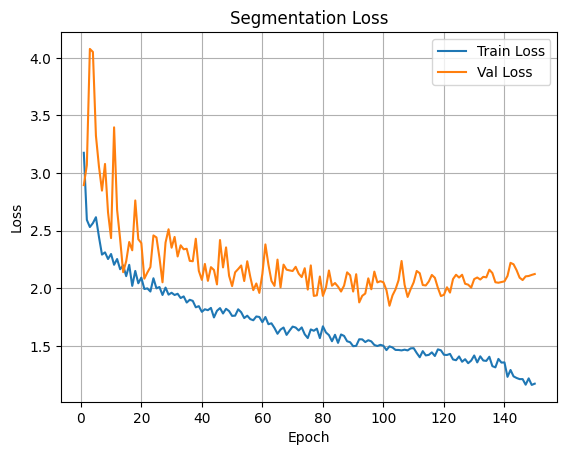

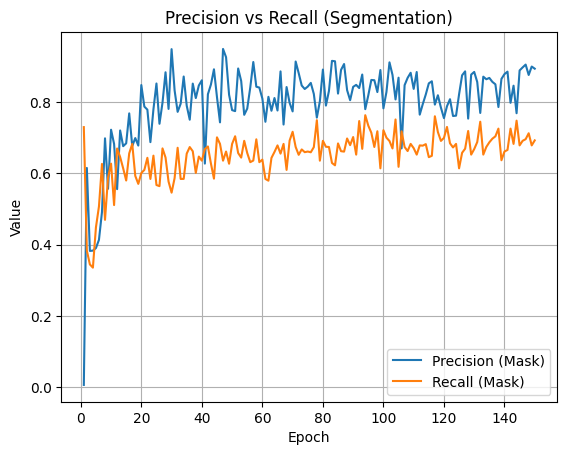

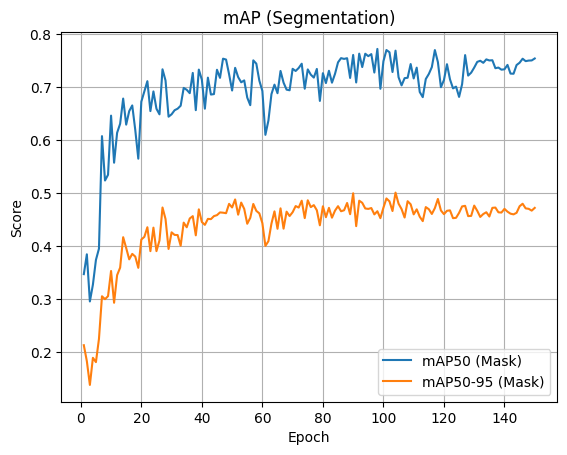

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('runs/segment/train/results.csv')

# ===== Loss Curves =====
plt.figure()
plt.plot(df['epoch'], df['train/seg_loss'], label='Train Loss')
plt.plot(df['epoch'], df['val/seg_loss'], label='Val Loss')
plt.title('Segmentation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


# ===== Precision & Recall (MASK) =====
plt.figure()
plt.plot(df['epoch'], df['metrics/precision(M)'], label='Precision (Mask)')
plt.plot(df['epoch'], df['metrics/recall(M)'], label='Recall (Mask)')
plt.title('Precision vs Recall (Segmentation)')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()


# ===== mAP (MASK) =====
plt.figure()
plt.plot(df['epoch'], df['metrics/mAP50(M)'], label='mAP50 (Mask)')
plt.plot(df['epoch'], df['metrics/mAP50-95(M)'], label='mAP50-95 (Mask)')
plt.title('mAP (Segmentation)')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()

In [12]:
results = model.predict(
    source = '/content/Fire-and-Smoke-Segmentation-1/test/images/flare_0060_jpg.rf.5932c0da5a20f649b046c73e936c9b5c.jpg',
    save = True,
)


image 1/1 /content/Fire-and-Smoke-Segmentation-1/test/images/flare_0060_jpg.rf.5932c0da5a20f649b046c73e936c9b5c.jpg: 640x640 1 fire, 1 smoke, 17.7ms
Speed: 2.5ms preprocess, 17.7ms inference, 11.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict


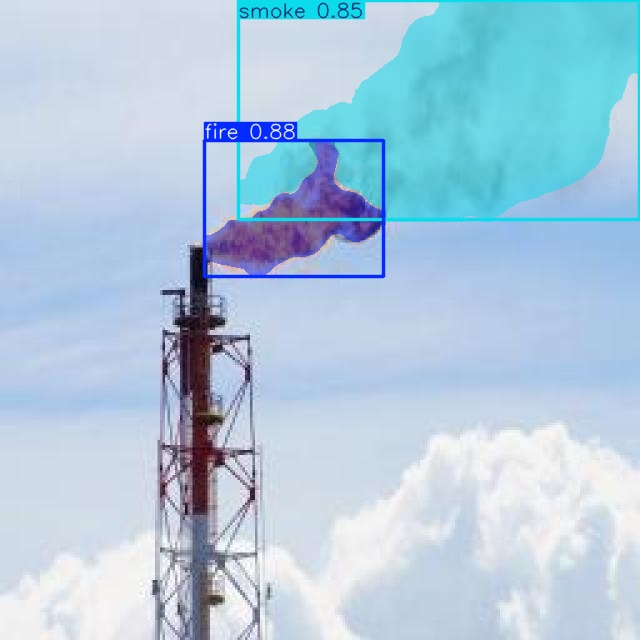

In [13]:
from IPython.display import Image, display
import glob

images = glob.glob('runs/segment/predict/*.jpg')

for img in images[:5]:
    display(Image(filename=img))